# Gym Churn Analysis

# ============================
# Paso 1: Cargar librerías y datos
# ============================

In [1]:
# Importar librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
# Cargar dataset
df = pd.read_csv("/datasets/gym_churn_us.csv")
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Ver info general y tipos de datos
print("\nInformación general:")
df.info()

# Revisar si hay valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total         

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


# ============================
# Paso 2: EDA - Análisis exploratorio
# ============================

In [4]:
# Comparar características por churn
print("\nValores medios por Churn:")
display(df.groupby('Churn').mean())


Valores medios por Churn:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


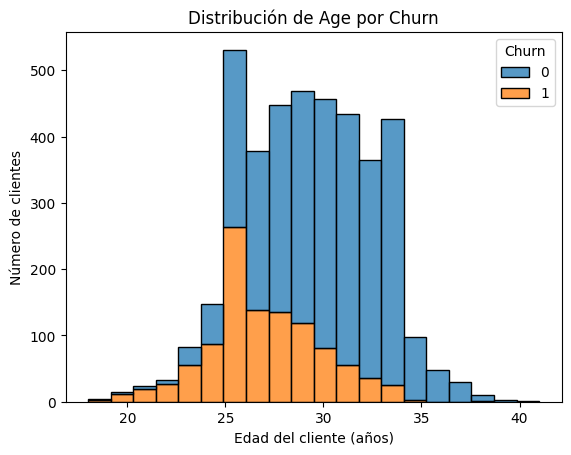

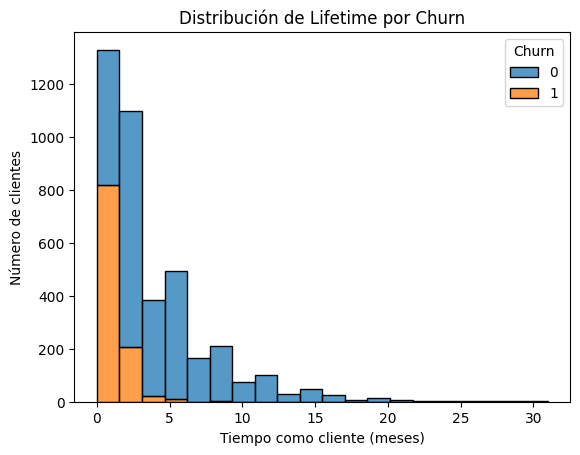

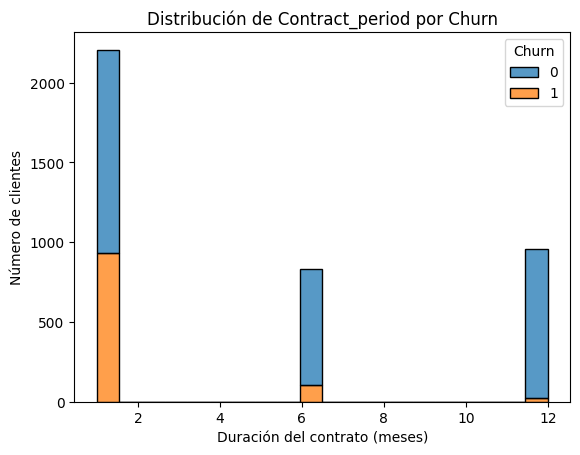

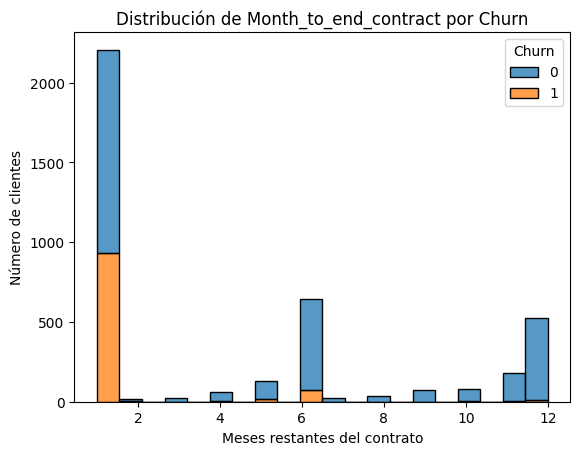

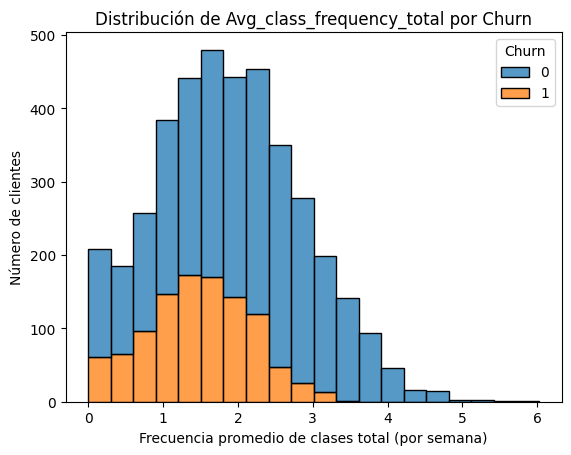

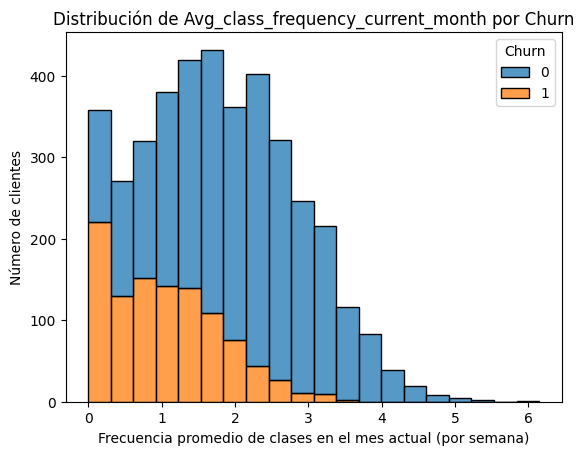

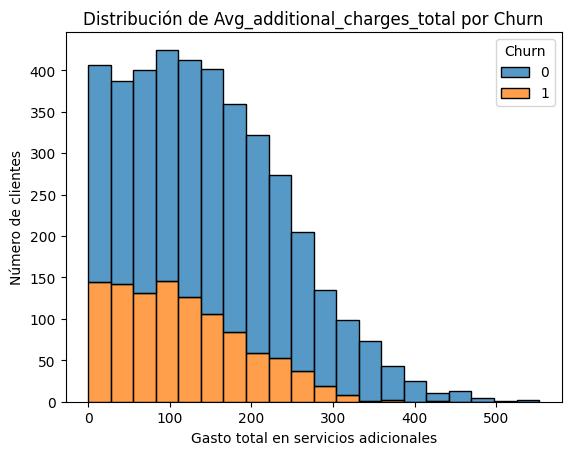

In [5]:

# Histogramas para variables numéricas con etiquetas más específicas
numeric_features = ['Age', 'Lifetime', 'Contract_period', 'Month_to_end_contract',
                    'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
                    'Avg_additional_charges_total']

# Diccionario para etiquetas X más descriptivas
x_labels = {
    'Age': 'Edad del cliente (años)',
    'Lifetime': 'Tiempo como cliente (meses)',
    'Contract_period': 'Duración del contrato (meses)',
    'Month_to_end_contract': 'Meses restantes del contrato',
    'Avg_class_frequency_total': 'Frecuencia promedio de clases total (por semana)',
    'Avg_class_frequency_current_month': 'Frecuencia promedio de clases en el mes actual (por semana)',
    'Avg_additional_charges_total': 'Gasto total en servicios adicionales'
}

for feature in numeric_features:
    sns.histplot(data=df, x=feature, hue='Churn', multiple='stack', bins=20)
    plt.title(f'Distribución de {feature} por Churn')
    plt.xlabel(x_labels[feature])
    plt.ylabel("Número de clientes")
    plt.show()


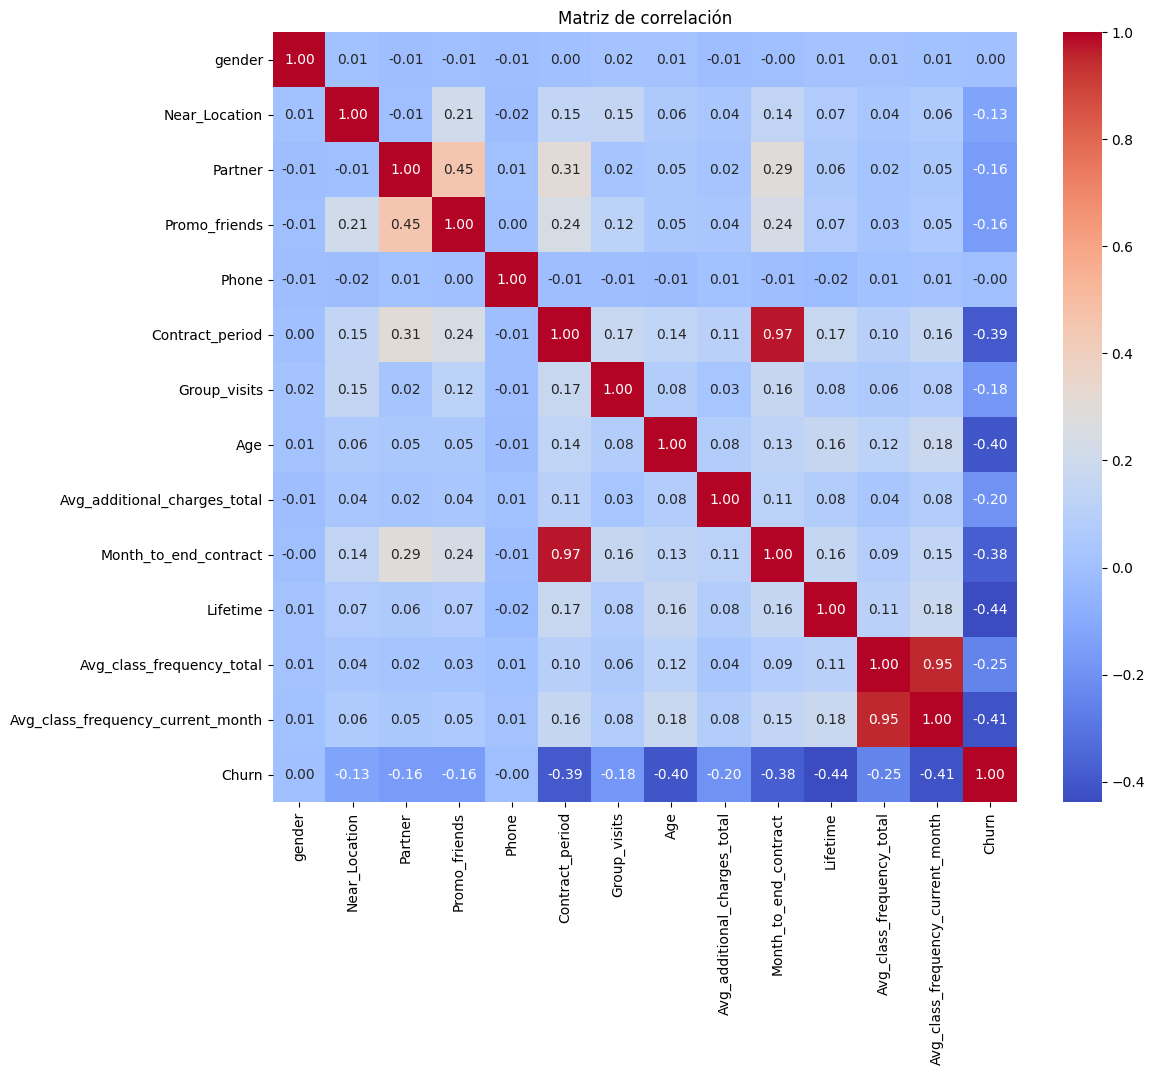

In [6]:
# Correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# ============================
# Paso 3: Modelos de predicción de churn
# ============================

In [7]:
# Preparar datos
X = df.drop(columns=['Churn'])
y = df['Churn']

# Convertir variables categóricas
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresión logística
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_val)

# Bosque aleatorio
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)


In [8]:
# Evaluar modelos:
# Evaluación de modelos
for name, y_pred in [('Regresión Logística', y_pred_log), ('Bosque Aleatorio', y_pred_rf)]:
    print(f"\n{name}:")
    print("Accuracy:", round(accuracy_score(y_val, y_pred), 3))
    print("Precision:", round(precision_score(y_val, y_pred), 3))
    print("Recall:", round(recall_score(y_val, y_pred), 3))

# Nota: compara cuál modelo predice mejor el churn.


Regresión Logística:
Accuracy: 0.916
Precision: 0.873
Recall: 0.782

Bosque Aleatorio:
Accuracy: 0.91
Precision: 0.849
Recall: 0.782


# ============================
# Paso 4: Clustering de usuarios
# ============================

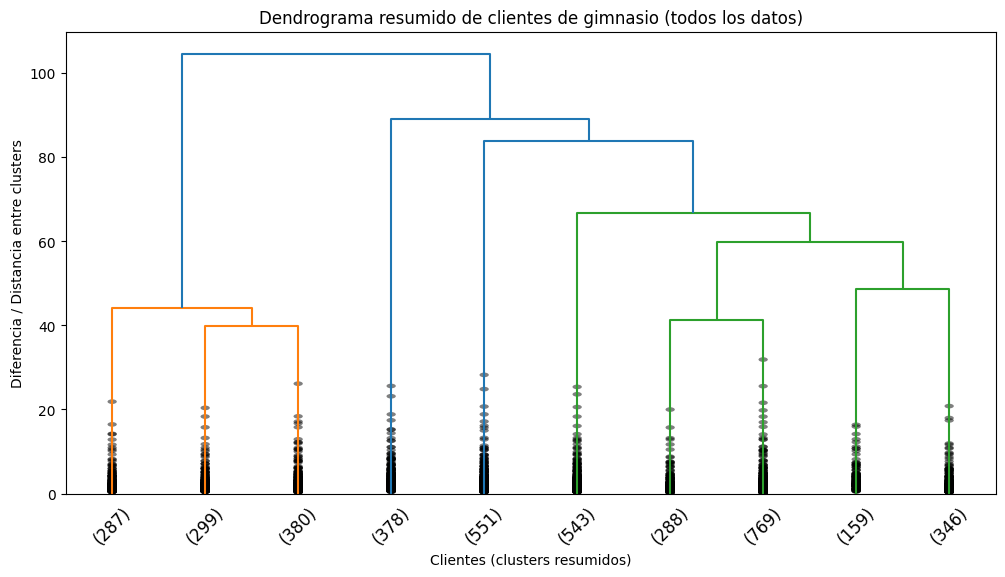

In [9]:
# Preparar datos para clustering (sin Churn)
X_cluster = df.drop(columns=['Churn'])
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Dendrograma completo con etiquetas de ejes
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp', 
    p=10, 
    leaf_rotation=45, 
    leaf_font_size=12, 
    show_contracted=True
)

# Añadir títulos y etiquetas de ejes
plt.title("Dendrograma resumido de clientes de gimnasio (todos los datos)")
plt.xlabel("Clientes (clusters resumidos)")
plt.ylabel("Diferencia / Distancia entre clusters")
plt.show()

# K-means con n=5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [10]:
# Valores medios por cluster
print("\nValores medios por cluster:")
display(df.groupby('Cluster').mean())

# Tasa de churn por cluster
print("\nTasa de cancelación por cluster:")
display(df.groupby('Cluster')['Churn'].mean())

# Nota: Identificá qué clusters son más propensos a abandonar y cuáles son más leales.


Valores medios por cluster:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839



Tasa de cancelación por cluster:


Cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

# ============================
# Paso 5: Conclusiones y recomendaciones
# ============================

Conclusiones y recomendaciones:

1. Los clientes que participan en clases grupales y tienen contratos largos son más leales.
2. Los clientes con baja frecuencia de visitas y sin interacción digital son más propensos a cancelar.
3. Algunos clusters muestran alta inversión en servicios adicionales, indicando clientes comprometidos.

Recomendaciones:
- Incentivar asistencia a clases grupales para clientes con baja frecuencia.
- Enviar recordatorios personalizados a clientes con contrato próximo a terminar.
- Promociones 'trae a un amigo' y fidelización de empleados de empresas asociadas.
- Monitoreo proactivo de clientes inactivos antes de la cancelación.
